### Install Dependencies

In [1]:
!pip install torch torchvision compressai 

import os
if not os.path.exists('U-2-Net'):
    !git clone https://github.com/xuebinqin/U-2-Net.git
    print('U-2-Net cloned.')
else:
    print('U-2-Net already present.')

# Download pretrained U2Net weights (~170 MB)
if not os.path.exists('u2net.pth'):
    print('Download u2net.pth from:')
    print('  https://drive.google.com/file/d/1ao1ovG1Qtx4b7EoskHXmi2E9rp5CHLcZ')
    print('Place it in the current directory as u2net.pth')
else:
    print('u2net.pth found.')

U-2-Net cloned.
Download u2net.pth from:
  https://drive.google.com/file/d/1ao1ovG1Qtx4b7EoskHXmi2E9rp5CHLcZ
Place it in the current directory as u2net.pth


## Section 2 — Imports

In [2]:
import sys, os, math
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from tqdm import tqdm
from scipy.interpolate import PchipInterpolator
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader

from compressai.layers import GDN
from compressai.entropy_models import EntropyBottleneck, GaussianConditional

# Add U-2-Net to path
sys.path.insert(0, 'U-2-Net')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"Number of GPUs: {torch.cuda.device_count()}")

    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

Using device: cuda
Number of GPUs: 2
GPU 0: Tesla T4
GPU 1: Tesla T4


In [5]:
class PretrainedU2NetSaliency(nn.Module):
    """
    Wraps pretrained U²-Net as a frozen saliency predictor.
    Returns raw logits (no sigmoid), matching the paper's Eq. (1):
        w = D(I, Φ)  — distance of each pixel to the hyperplane.
    Falls back to a lightweight CNN if weights are not available.
    """

    def __init__(self, weights_path='u2net.pth'):
        super().__init__()
        self.use_u2net = os.path.exists(weights_path) 

        if self.use_u2net:
            from model.u2net import U2NET
            self.net = U2NET(3, 1)
            state = torch.load(weights_path, map_location='cpu')
            self.net.load_state_dict(state)
            # Freeze — paper keeps saliency and compression networks decoupled
            for p in self.net.parameters():
                p.requires_grad = False
            print('[SaliencyPredictor] Loaded pretrained U²-Net (frozen).')
        else:
            # Lightweight fallback CNN
            self.net = nn.Sequential(
                nn.Conv2d(3,  32, 3, padding=1), nn.ReLU(),
                nn.Conv2d(32, 64, 3, padding=1, stride=2), nn.ReLU(),
                nn.Conv2d(64,128, 3, padding=1, stride=2), nn.ReLU(),
                nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1), nn.ReLU(),
                nn.ConvTranspose2d(64,  32, 4, stride=2, padding=1), nn.ReLU(),
                nn.Conv2d(32, 1, 1),
            )
            print('[SaliencyPredictor] U²-Net weights not found — using trainable fallback CNN.')

    def forward(self, x):
        if self.use_u2net:
            # U2Net returns 7 outputs; d0 is the finest-scale prediction
            with torch.no_grad():
                d0, *_ = self.net(x)
            return d0   # raw logits (B, 1, H, W)
        else:
            return self.net(x)


# Quick test
sal_net = PretrainedU2NetSaliency('/kaggle/input/models/priyanshu202311067/u2net/pytorch/default/1/u2net.pth')
dummy   = torch.rand(1, 3, 128, 128)
out     = sal_net(dummy)
print(f'Saliency output shape: {out.shape}')  # (1, 1, 128, 128)

[SaliencyPredictor] U²-Net weights not found — using trainable fallback CNN.
Saliency output shape: torch.Size([1, 1, 128, 128])


### ACRD Function 

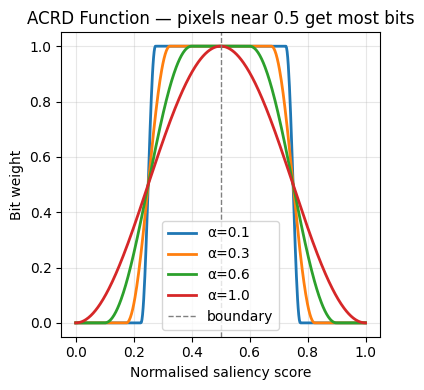

In [4]:
def acrd(x: torch.Tensor, alpha: float = 0.6) -> torch.Tensor:
    """
    Ascending Cosine Roll-Down (ACRD) — Eq. 3.
    Pixels with saliency score near 0.5 (decision boundary) receive
    the highest bit-allocation weight.

    Args:
        x:     Normalised saliency scores ∈ [0,1]
        alpha: Bandwidth factor (paper uses α=0.6)
    Returns:
        Bit allocation weights ∈ [0,1], same shape as x
    """
    dist        = (x - 0.5).abs()
    flat_thresh = (1 - alpha) / 4
    zero_thresh = (1 + alpha) / 4
    cosine_part = torch.cos(math.pi / alpha * (dist - flat_thresh)) ** 2

    return torch.where(dist < flat_thresh,  torch.ones_like(x),
           torch.where(dist > zero_thresh,  torch.zeros_like(x),
                                            cosine_part))


# Visualise
x_vals = torch.linspace(0, 1, 500)
plt.figure(figsize=(4, 4))
for alpha in [0.1, 0.3, 0.6, 1.0]:
    plt.plot(x_vals.numpy(), acrd(x_vals, alpha).numpy(), label=f'α={alpha}', linewidth=2)
plt.axvline(0.5, color='gray', linestyle='--', linewidth=1, label='boundary')
plt.xlabel('Normalised saliency score'); plt.ylabel('Bit weight')
plt.title('ACRD Function — pixels near 0.5 get most bits')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

In [5]:
class Encoder(nn.Module):
    
    def __init__(self, C: int = 64):
        super().__init__()
        self.C  = C
        self.Cb = 3 * C // 4
        self.Ce = C // 4

        N1 = max(32,  C // 2)
        N2 = max(48,  3 * C // 4)
        N3 = max(48,  3 * C // 4)

        self.net = nn.Sequential(
            nn.Conv2d(3,  N1, 5, stride=2, padding=2), GDN(N1),   # /2
            nn.Conv2d(N1, N2, 5, stride=2, padding=2), GDN(N2),   # /4
            nn.Conv2d(N2, N3, 5, stride=2, padding=2), GDN(N3),   # /8
            nn.Conv2d(N3, C,  5, stride=2, padding=2),             # /16
        )

    def forward(self, x):
        y  = self.net(x)
        fb = y[:, :self.Cb]
        fe = y[:,  self.Cb:]
        return y, fb, fe


class Decoder(nn.Module):
    
    def __init__(self, C: int = 64, output_size: int = 256):
        super().__init__()
        self.output_size = output_size

        N1 = max(32,  C // 2)
        N2 = max(48,  3 * C // 4)
        N3 = max(48,  3 * C // 4)

        self.net = nn.Sequential(
            nn.ConvTranspose2d(C,  N3, 5, stride=2, padding=2, output_padding=1), GDN(N3, inverse=True),  # ×2
            nn.ConvTranspose2d(N3, N2, 5, stride=2, padding=2, output_padding=1), GDN(N2, inverse=True),  # ×2
            nn.ConvTranspose2d(N2, N1, 5, stride=2, padding=2, output_padding=1), GDN(N1, inverse=True),  # ×2
            nn.ConvTranspose2d(N1, 3,  5, stride=2, padding=2, output_padding=1),                         # ×2
        )

    def forward(self, y):
        x = self.net(y)
        # Safety: force output to exactly match input image size
        # This handles any off-by-one from ConvTranspose2d padding
        if x.shape[-1] != self.output_size or x.shape[-2] != self.output_size:
            x = F.interpolate(x, size=(self.output_size, self.output_size),
                              mode='bilinear', align_corners=False)
        return torch.sigmoid(x)

 Double-Scale Entropy Module

In [6]:
class DoubleScaleEntropyModule(nn.Module):
    def __init__(self, Cb: int = 192, Ce: int = 64, N: int = 128):
        super().__init__()
        self.Cb = Cb
        self.Ce = Ce

        # ---- Hyperprior for base channels (Eq. 7a) ----
        self.hyper_enc = nn.Sequential(
            nn.Conv2d(Cb, N, 3, padding=1),               nn.LeakyReLU(inplace=True),
            nn.Conv2d(N,  N, 5, stride=2, padding=2),     nn.LeakyReLU(inplace=True),
            nn.Conv2d(N,  N, 5, stride=2, padding=2),
        )
        self.hyper_dec = nn.Sequential(
            nn.ConvTranspose2d(N, N, 5, stride=2, padding=2, output_padding=1), nn.LeakyReLU(inplace=True),
            nn.ConvTranspose2d(N, N, 5, stride=2, padding=2, output_padding=1), nn.LeakyReLU(inplace=True),
            nn.Conv2d(N, Cb * 2, 3, padding=1),   # outputs mean + scale for Gaussian
        )
        self.entropy_z  = EntropyBottleneck(N)          # for hyperlatent z
        self.gaussian_b = GaussianConditional(None)     # for base fb

        # ---- Factorized entropy for enhancement channels (Eq. 7b) ----
        self.entropy_e  = EntropyBottleneck(Ce)

    def forward(self, fb, fe_masked):
        """
        Args:
            fb:        base latent      (B, Cb, H, W)
            fe_masked: masked enhancement (B, Ce, H, W)
        Returns:
            fb_hat, fe_hat:       quantised reconstructed features
            likelihoods dict:     for rate computation
        """
        # Hyperprior path
        z               = self.hyper_enc(fb)
        z_hat, z_lls    = self.entropy_z(z)
        params          = self.hyper_dec(z_hat)
        means, scales   = params.chunk(2, dim=1)
        fb_hat, fb_lls  = self.gaussian_b(fb, scales.abs() + 1e-6, means=means)

        # Factorized path
        fe_hat, fe_lls  = self.entropy_e(fe_masked)

        likelihoods = {'fb': fb_lls, 'z': z_lls, 'fe': fe_lls}
        return fb_hat, fe_hat, likelihoods

    def compress(self, fb, fe_masked):
        """Actual bitstream encoding (used at inference)."""
        z           = self.hyper_enc(fb)
        z_strings   = self.entropy_z.compress(z)
        z_hat       = self.entropy_z.decompress(z_strings, z.size()[-2:])
        params      = self.hyper_dec(z_hat)
        means, scales = params.chunk(2, dim=1)

        indexes     = self.gaussian_b.build_indexes(scales.abs() + 1e-6)
        fb_strings  = self.gaussian_b.compress(fb, indexes, means=means)
        fe_strings  = self.entropy_e.compress(fe_masked)
        return {'fb': fb_strings, 'z': z_strings, 'fe': fe_strings,
                'shape': z.size()[-2:]}

    def decompress(self, strings, shape, fh, fw):
        """Actual bitstream decoding."""
        z_hat     = self.entropy_z.decompress(strings['z'], shape)
        params    = self.hyper_dec(z_hat)
        means, scales = params.chunk(2, dim=1)
        indexes   = self.gaussian_b.build_indexes(scales.abs() + 1e-6)
        fb_hat    = self.gaussian_b.decompress(strings['fb'], indexes, means=means)
        fe_hat    = self.entropy_e.decompress(strings['fe'], [fh, fw])
        return fb_hat, fe_hat


print('DoubleScaleEntropyModule defined.')

DoubleScaleEntropyModule defined.


Bit Allocation Module

In [1]:
class BitAllocationModule(nn.Module):

    def __init__(self, C: int = 256, alpha: float = 0.6):
        super().__init__()
        self.C     = C
        self.Ce    = C // 4
        self.Cb    = C - self.Ce
        self.alpha = alpha

    def forward(self, logits: torch.Tensor, fh: int, fw: int):
        B = logits.size(0)

    
        w      = torch.sigmoid(logits)                            # (B,1,H,W)

        w      = F.interpolate(w, (fh, fw), mode='bilinear', align_corners=False)

        wf     = w.view(B, -1)
        w_min  = wf.min(1)[0].view(B,1,1,1)
        w_max  = wf.max(1)[0].view(B,1,1,1)
        w_norm = (w - w_min) / (w_max - w_min + 1e-8)

        # ACRD 
        W      = acrd(w_norm, self.alpha)                         # (B,1,fh,fw)

        #  3D binary mask M
        base_mask = torch.ones(B, self.Cb, fh, fw, device=logits.device)
        keep      = (self.Ce * W).round().long().clamp(0, self.Ce)
        ch_idx    = torch.arange(self.Ce, device=logits.device).view(1, self.Ce, 1, 1)
        enh_mask  = (ch_idx < keep).float()
        M         = torch.cat([base_mask, enh_mask], dim=1)       # (B,C,fh,fw)

        return W, M


print('BitAllocationModule defined.')

NameError: name 'nn' is not defined

##Full Compression Model

In [8]:
class SaliencyCompressionModel(nn.Module):
   
    
    def __init__(self, C: int = 64, alpha: float = 0.6,
                 output_size: int = 256,              # ← add this
                 u2net_weights: str = '/kaggle/input/models/pmatraith/u2net/pytorch/default/1/u2net.pth'):
        super().__init__()
        self.C           = C
        self.Cb          = 3 * C // 4
        self.Ce          = C // 4
        self.output_size = output_size                # ← store it

        self.saliency  = PretrainedU2NetSaliency(u2net_weights)
        self.encoder   = Encoder(C)
        self.decoder   = Decoder(C, output_size)      # ← pass it here
        self.bit_alloc = BitAllocationModule(C, alpha)
        self.entropy   = DoubleScaleEntropyModule(Cb=self.Cb, Ce=self.Ce)

    def forward(self, x, inference: bool = False):
        # 1. Saliency prediction
        logits         = self.saliency(x)              # (B,1,H,W)

        # 2. Encode
        y, fb, fe      = self.encoder(x)               # (B,C,H/16,W/16)
        fh, fw         = y.shape[2], y.shape[3]

        # 3. Bit allocation map + mask
        W, M           = self.bit_alloc(logits, fh, fw)

        if inference:
            # Apply mask and decode
            fe_masked  = M[:, self.Cb:] * fe
            fb_hat, fe_hat, _ = self.entropy(fb, fe_masked)
            y_hat      = torch.cat([fb_hat, fe_hat], dim=1)
            x_hat      = self.decoder(y_hat)
            return x_hat, W, M

        else:
            fe0            = torch.zeros_like(fe)
            fb_hat0, fe_hat0, lls0 = self.entropy(fb, fe0)
            y_base         = torch.cat([fb_hat0, fe_hat0], dim=1)
            x_base         = self.decoder(y_base)

            fe_masked      = M[:, self.Cb:] * fe
            fb_hat,  fe_hat,  lls  = self.entropy(fb, fe_masked)
            y_enh          = torch.cat([fb_hat, fe_hat], dim=1)
            x_enh          = self.decoder(y_enh)

            return x_base, x_enh, W, lls0, lls

    def compress_image(self, x):
        """Full compression to bitstream (inference)."""
        self.eval()
        with torch.no_grad():
            logits     = self.saliency(x)
            y, fb, fe  = self.encoder(x)
            fh, fw     = y.shape[2], y.shape[3]
            W, M       = self.bit_alloc(logits, fh, fw)
            fe_masked  = M[:, self.Cb:] * fe
            strings    = self.entropy.compress(fb, fe_masked)
        return strings, fh, fw, W

    def decompress_image(self, strings, fh, fw):
        """Full decompression from bitstream."""
        self.eval()
        with torch.no_grad():
            fb_hat, fe_hat = self.entropy.decompress(strings, strings['shape'], fh, fw)
            y_hat          = torch.cat([fb_hat, fe_hat], dim=1)
            x_hat          = self.decoder(y_hat)
        return x_hat


model_test = SaliencyCompressionModel(C=64, alpha=0.6,
    u2net_weights='/kaggle/input/models/pmatraith/u2net/pytorch/default/1/u2net.pth'
).to(device)
x_dummy    = torch.rand(2, 3, 128, 128).to(device)
x_base, x_enh, W, lls0, lls = model_test(x_dummy, inference=False)
print(f'Base recon:     {x_base.shape}')
print(f'Enhanced recon: {x_enh.shape}')
print(f'Allocation map: {W.shape}')
print(f'Likelihoods keys: {list(lls.keys())}')

[SaliencyPredictor] U²-Net weights not found — using trainable fallback CNN.
Base recon:     torch.Size([2, 3, 256, 256])
Enhanced recon: torch.Size([2, 3, 256, 256])
Allocation map: torch.Size([2, 1, 8, 8])
Likelihoods keys: ['fb', 'z', 'fe']


In [9]:
def rate_distortion_loss(
    x:       torch.Tensor,
    x_base:  torch.Tensor,
    x_enh:   torch.Tensor,
    lls0:    dict,          # likelihoods from base branch
    lls:     dict,          # likelihoods from enhanced branch
    lambda_b: float = 0.001,
    lambda_e: float = 0.003,
    alpha_b:  float = 2.0,
) -> dict:

    N, _, H, W = x.shape

    def bpp(ll_dict, keys):
        total = sum(-ll_dict[k].log2().sum() for k in keys)
        return total / (N * H * W)

    R_b  = bpp(lls0, ['fb', 'z', 'fe'])
    R_e  = bpp(lls,  ['fb', 'z', 'fe'])
    D_b  = F.mse_loss(x_base, x)
    D_e  = F.mse_loss(x_enh,  x)

    loss = alpha_b * (R_b + lambda_b * D_b) + (R_e + lambda_e * D_e)

    return {
        'loss': loss,
        'R_b':  R_b.item(),  'R_e':  R_e.item(),
        'D_b':  D_b.item(),  'D_e':  D_e.item(),
        'bpp_base': R_b.item(), 'bpp_enh': R_e.item(),
    }


print('Rate-distortion loss defined.')

Rate-distortion loss defined.


In [10]:
class ImagePatchDataset(Dataset):
    def __init__(
        self,
        root: str,
        patch_size: int = 256,
        split: str = 'train',
        max_images: int = None
    ):
        root = Path(root)

        exts = {'.png', '.jpg', '.jpeg', '.bmp', '.webp'}

        self.files = sorted([
            f for f in root.rglob('*')
            if f.suffix.lower() in exts
        ])

        if len(self.files) == 0:
            raise FileNotFoundError(
                f'No images found in {root}'
            )

        # use same base pool for both train and val
        if max_images is not None:
            self.files = self.files[:max_images]

        # consistent 90/10 split
        split_idx = int(0.9 * len(self.files))

        if split == 'train':
            self.files = self.files[:split_idx]
        else:
            self.files = self.files[split_idx:]

        self.transform = T.Compose([
            T.RandomCrop(patch_size),
            T.RandomHorizontalFlip(),
            T.ToTensor(),
        ])

        print(
            f'[Dataset] {split}: '
            f'{len(self.files)} images from {root}'
        )

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(
            self.files[idx]
        ).convert('RGB')

        if min(img.size) < 256:
            img = T.Resize(256)(img)

        return self.transform(img)


DATA_ROOT = '/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017'

MAX_IMAGES = 5000


if DATA_ROOT and Path(DATA_ROOT).exists():

    train_dataset = ImagePatchDataset(
        DATA_ROOT,
        patch_size=256,
        split='train',
        max_images=MAX_IMAGES
    )

    val_dataset = ImagePatchDataset(
        DATA_ROOT,
        patch_size=256,
        split='val',
        max_images=MAX_IMAGES
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=32,
        shuffle=True,
        num_workers=4,
        pin_memory=True,
        drop_last=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=16,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    print('Real dataset loaded.')

else:
    print(
        'DATA_ROOT not set — using synthetic data for demonstration.'
    )

    synthetic = torch.rand(64, 3, 256, 256)

    train_loader = DataLoader(
        torch.utils.data.TensorDataset(synthetic[:56]),
        batch_size=8,
        shuffle=True
    )

    val_loader = DataLoader(
        torch.utils.data.TensorDataset(synthetic[56:]),
        batch_size=4,
        shuffle=False
    )

[Dataset] train: 4500 images from /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017
[Dataset] val: 500 images from /kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017
Real dataset loaded.


Training Setup



In [11]:

QUALITY_LEVELS = [
    (2.0, 0.0009, 0.003),   # Q1 — low bpp
    (2.5, 0.001,  0.005),   # Q2
    (3.0, 0.002,  0.016),   # Q3
    (4.0, 0.005,  0.045),   # Q4
    (5.0, 0.015,  0.008),   # Q5 — high bpp
]

QUALITY = 2
alpha_b, lambda_b, lambda_e = QUALITY_LEVELS[QUALITY]
print(f'Training Quality Level {QUALITY+1}: α_b={alpha_b}, λ_b={lambda_b}, λ_e={lambda_e}')


C = 256  # change to 256 for full paper performance
model = SaliencyCompressionModel(C=C, alpha=0.6).to(device)
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

model = model.to(device)

compression_params = [
    p for n, p in model.named_parameters()
    if not n.startswith('saliency') and p.requires_grad
]
print(f'Trainable parameters: {sum(p.numel() for p in compression_params):,}')

optimizer = torch.optim.Adam(compression_params, lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=10, factor=0.5
)

if isinstance(model, nn.DataParallel):
    model.module.entropy.entropy_z.update()
    model.module.entropy.entropy_e.update()
else:
    model.entropy.entropy_z.update()
    model.entropy.entropy_e.update()

print('Model and optimizer ready.')

Training Quality Level 3: α_b=3.0, λ_b=0.002, λ_e=0.016
[SaliencyPredictor] U²-Net weights not found — using trainable fallback CNN.
Using 2 GPUs
Trainable parameters: 8,303,236
Model and optimizer ready.


## Section 12 — Training Loop

In [ ]:
EPOCHS =  150    
CLIP_NORM = 1.0    
LOG_EVERY = 5
CHECKPOINT = '/kaggle/working/saliency_compression_ckpt.pth'

history = {
    'train_loss': [],
    'val_loss': [],
    'train_bpp': [],
    'val_bpp': []
}


def run_epoch(loader, train=True):
    model.train() if train else model.eval()

    total_loss = 0
    total_bpp = 0
    n_batches = 0

    ctx = torch.enable_grad() if train else torch.no_grad()

    with ctx:
        for batch in loader:
            # Handle both TensorDataset (tuple) and plain tensor
            x = batch[0] if isinstance(batch, (list, tuple)) else batch
            x = x.to(device)

            if train:
                optimizer.zero_grad()

            x_base, x_enh, W, lls0, lls = model(
                x,
                inference=False
            )

            out = rate_distortion_loss(
                x,
                x_base,
                x_enh,
                lls0,
                lls,
                lambda_b=lambda_b,
                lambda_e=lambda_e,
                alpha_b=alpha_b
            )

            if train:
                out['loss'].backward()

                nn.utils.clip_grad_norm_(
                    compression_params,
                    CLIP_NORM
                )

                optimizer.step()

            total_loss += out['loss'].item()
            total_bpp += out['bpp_enh']
            n_batches += 1

    return total_loss / n_batches, total_bpp / n_batches


best_val = float('inf')

for epoch in range(1, EPOCHS + 1):

    # -------------------------
    # TRAIN + VALIDATION
    # -------------------------
    tr_loss, tr_bpp = run_epoch(train_loader, train=True)
    vl_loss, vl_bpp = run_epoch(val_loader, train=False)

    # -------------------------
    # SCHEDULER + HISTORY
    # -------------------------
    scheduler.step(vl_loss)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_bpp'].append(tr_bpp)
    history['val_bpp'].append(vl_bpp)

    # -------------------------
    # SAVE CHECKPOINT EVERY 10 EPOCHS
    # -------------------------
    if epoch % 100 == 0:
        checkpoint = {
            'epoch': epoch,
            'model': model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'scheduler': scheduler.state_dict(),
            'best_val': best_val,
            'history': history,
            'train_loss': tr_loss,
            'val_loss': vl_loss,
            'train_bpp': tr_bpp,
            'val_bpp': vl_bpp
        }

        torch.save(
            checkpoint,
            f"/kaggle/working/checkpoint_epoch_{epoch}.pth"
        )

        print(f"Checkpoint saved at epoch {epoch}")

    # -------------------------
    # SAVE BEST MODEL
    # -------------------------
    if vl_loss < best_val:
        best_val = vl_loss

        best_checkpoint = {
            'epoch': epoch,
            'model': model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'scheduler': scheduler.state_dict(),
            'best_val': best_val,
            'history': history
        }

        torch.save(
            best_checkpoint,
            CHECKPOINT
        )

    # -------------------------
    # LOGGING
    # -------------------------
    if epoch % LOG_EVERY == 0 or epoch == 1:
        print(
            f"Epoch {epoch:4d}/{EPOCHS} | "
            f"Train loss={tr_loss:.4f} bpp={tr_bpp:.3f} | "
            f"Val loss={vl_loss:.4f} bpp={vl_bpp:.3f}"
        )


print(f"\nBest val loss: {best_val:.4f}")
print(f"Best checkpoint saved at: {CHECKPOINT}")

# -------------------------
# PLOT TRAINING CURVES
# -------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'], label='Val')
ax1.set_title('R-D Loss')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history['train_bpp'], label='Train')
ax2.plot(history['val_bpp'], label='Val')
ax2.set_title('Bitrate (bpp)')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Epoch    1/150 | Train loss=0.5057 bpp=0.126 | Val loss=0.0050 bpp=0.001
Epoch    5/150 | Train loss=0.4984 bpp=0.124 | Val loss=0.0048 bpp=0.001
Epoch   10/150 | Train loss=0.4908 bpp=0.122 | Val loss=0.0047 bpp=0.001
Epoch   15/150 | Train loss=0.4849 bpp=0.121 | Val loss=0.0045 bpp=0.001
Epoch   20/150 | Train loss=0.4799 bpp=0.120 | Val loss=0.0039 bpp=0.001
Epoch   25/150 | Train loss=0.4758 bpp=0.119 | Val loss=0.0029 bpp=0.000
Epoch   30/150 | Train loss=0.4725 bpp=0.118 | Val loss=0.0024 bpp=0.000
Epoch   35/150 | Train loss=0.4698 bpp=0.117 | Val loss=0.0022 bpp=0.000
Epoch   40/150 | Train loss=0.4676 bpp=0.116 | Val loss=0.0022 bpp=0.000


## Section 13 — Inference & Full Visualisation

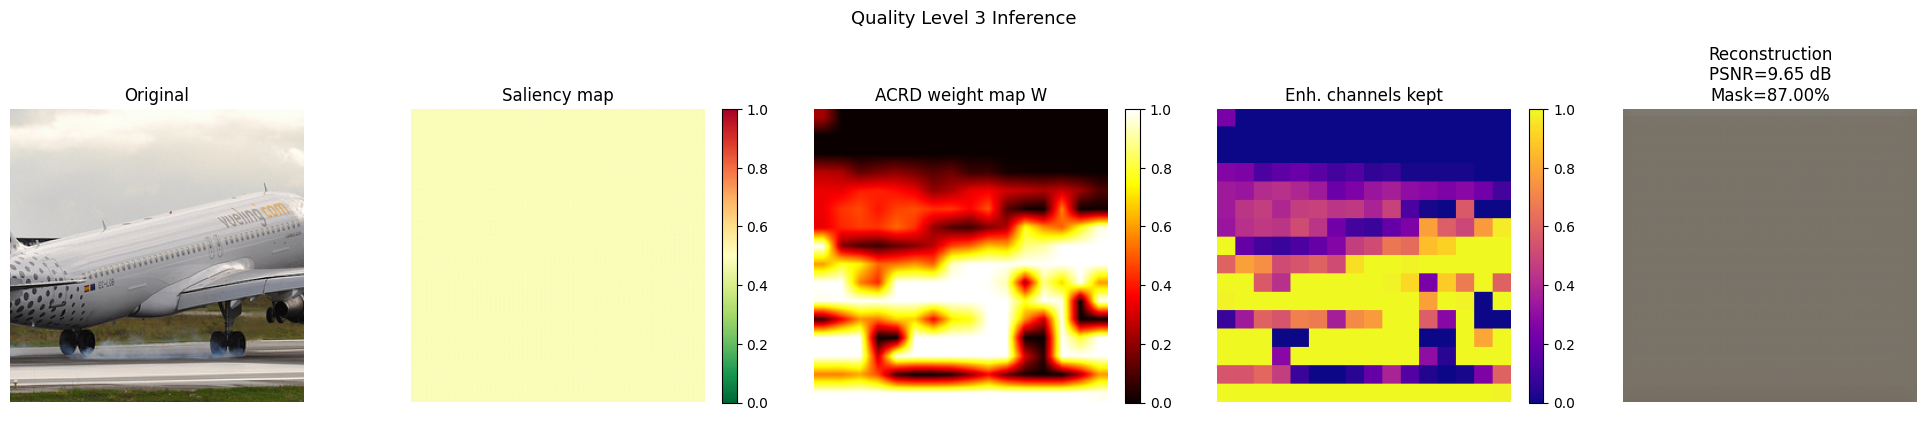

In [13]:
def compute_psnr(orig, recon):
    mse = np.mean((orig - recon) ** 2)
    return -10 * np.log10(mse + 1e-8)


def compute_ms_ssim(orig_t, recon_t):
    """Simple single-scale SSIM as proxy."""
    try:
        from torch.nn.functional import avg_pool2d

        C1, C2 = 0.01**2, 0.03**2

        mu1 = avg_pool2d(orig_t, 11, 1, 5)
        mu2 = avg_pool2d(recon_t, 11, 1, 5)

        s1 = avg_pool2d(orig_t**2, 11, 1, 5) - mu1**2
        s2 = avg_pool2d(recon_t**2, 11, 1, 5) - mu2**2
        s12 = avg_pool2d(orig_t * recon_t, 11, 1, 5) - mu1 * mu2

        ssim = (
            (2 * mu1 * mu2 + C1) * (2 * s12 + C2)
        ) / (
            (mu1**2 + mu2**2 + C1) * (s1 + s2 + C2)
        )

        return ssim.mean().item()

    except Exception:
        return float("nan")


def visualise_compression(model, x_tensor, title=''):
    """
    Full inference visualisation:
      Col 1: Original image
      Col 2: Saliency map
      Col 3: ACRD allocation weight map
      Col 4: Enhancement channels kept
      Col 5: Reconstructed image
    """

    model.eval()

    # support both normal model and DataParallel
    m = model.module if isinstance(model, nn.DataParallel) else model

    x_in = x_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = m.saliency(x_in)
        x_hat, W, M = m(x_in, inference=True)

    # -----------------------------
    # IMAGE ARRAYS
    # -----------------------------
    orig = x_tensor.cpu().permute(1, 2, 0).numpy().clip(0, 1)

    recon = (
        x_hat.squeeze(0)
        .cpu()
        .permute(1, 2, 0)
        .numpy()
        .clip(0, 1)
    )

    H, W_img = orig.shape[:2]

    # -----------------------------
    # UPSAMPLE SALIENCY MAP
    # -----------------------------
    sal_map = F.interpolate(
        torch.sigmoid(logits),
        size=(H, W_img),
        mode='bilinear',
        align_corners=False
    ).squeeze().cpu().numpy()

    # -----------------------------
    # UPSAMPLE WEIGHT MAP
    # -----------------------------
    w_map = F.interpolate(
        W,
        size=(H, W_img),
        mode='bilinear',
        align_corners=False
    ).squeeze().cpu().numpy()

    # -----------------------------
    # ENHANCEMENT CHANNELS KEPT
    # -----------------------------
    enh_kept = F.interpolate(
        M[:, m.Cb:].float().mean(dim=1, keepdim=True),
        size=(H, W_img),
        mode='nearest'
    ).squeeze().cpu().numpy()

    # -----------------------------
    # METRICS
    # -----------------------------
    psnr_val = compute_psnr(orig, recon)
    mask_ratio = M.float().mean().item()

    # -----------------------------
    # PLOT
    # -----------------------------
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))

    axes[0].imshow(orig)
    axes[0].set_title("Original")

    im1 = axes[1].imshow(
        sal_map,
        cmap='RdYlGn_r',
        vmin=0,
        vmax=1
    )
    axes[1].set_title("Saliency map")
    plt.colorbar(im1, ax=axes[1], fraction=0.046)

    im2 = axes[2].imshow(
        w_map,
        cmap='hot',
        vmin=0,
        vmax=1
    )
    axes[2].set_title("ACRD weight map W")
    plt.colorbar(im2, ax=axes[2], fraction=0.046)

    im3 = axes[3].imshow(
        enh_kept,
        cmap='plasma',
        vmin=0,
        vmax=1
    )
    axes[3].set_title("Enh. channels kept")
    plt.colorbar(im3, ax=axes[3], fraction=0.046)

    axes[4].imshow(recon)
    axes[4].set_title(
        f"Reconstruction\n"
        f"PSNR={psnr_val:.2f} dB\n"
        f"Mask={mask_ratio:.2%}"
    )

    for ax in axes:
        ax.axis("off")

    plt.suptitle(
        title or "Saliency-Oriented Deep Image Compression",
        fontsize=13,
        y=1.02
    )

    plt.tight_layout()
    plt.show()


# -----------------------------
# TEST ON SAMPLE
# -----------------------------
sample_batch = next(iter(val_loader))

sample_img = (
    sample_batch[0][0]
    if isinstance(sample_batch, (list, tuple))
    else sample_batch[0]
)

visualise_compression(
    model,
    sample_img,
    title="Quality Level 3 Inference"
)

In [19]:
class SODMetrics:
    
    @staticmethod
    def mae(pred: np.ndarray, gt: np.ndarray) -> float:
        return float(np.abs(pred - gt).mean())

    @staticmethod
    def f1_score(pred: np.ndarray, gt: np.ndarray,
                 threshold: float = 0.5, beta2: float = 1.0) -> float:
        pred_bin = (pred >= threshold).astype(float)
        gt_bin = (gt >= threshold).astype(float)

        TP = (pred_bin * gt_bin).sum()
        FP = (pred_bin * (1 - gt_bin)).sum()
        FN = ((1 - pred_bin) * gt_bin).sum()

        p = TP / (TP + FP + 1e-8)
        r = TP / (TP + FN + 1e-8)

        return float((1 + beta2) * p * r / (beta2 * p + r + 1e-8))

    @staticmethod
    def max_fbeta(pred: np.ndarray, gt: np.ndarray,
                  beta2: float = 0.3, n_thresh: int = 256) -> float:
        best = 0.0

        for thresh in np.linspace(0, 1, n_thresh):
            best = max(
                best,
                SODMetrics.f1_score(pred, gt, thresh, beta2)
            )

        return best

    @staticmethod
    def s_measure(pred: np.ndarray, gt: np.ndarray,
                  alpha: float = 0.5) -> float:

        gt_bin = (gt > 0.5).astype(float)
        pred_bin = (pred > 0.5).astype(float)

        Sr = float(np.corrcoef(pred.ravel(), gt.ravel())[0, 1])
        Sr = np.nan_to_num(Sr)
        Sr = (Sr + 1) / 2

        inter = (pred_bin * gt_bin).sum()
        So = float(
            2 * inter / (
                pred_bin.sum() + gt_bin.sum() + 1e-8
            )
        )

        return float(alpha * So + (1 - alpha) * Sr)


def evaluate_on_sod_dataset(model, images, gt_masks):
    model.eval()

    # support DataParallel
    m = model.module if isinstance(model, nn.DataParallel) else model

    maes, f1s, fbs, sms = [], [], [], []

    for img_t, gt in tqdm(
        zip(images, gt_masks),
        total=len(images),
        desc='Evaluating'
    ):

        with torch.no_grad():
            x_in = img_t.unsqueeze(0).to(device)

            # use actual inference path
            out = m(x_in, inference=True)

            # support different return formats
            if isinstance(out, tuple):
                x_hat = out[0]
            else:
                x_hat = out

            # saliency prediction
            sal_logit = m.saliency(x_hat)

            pred = torch.sigmoid(
                sal_logit
            ).squeeze().cpu().numpy()

        # resize prediction if needed
        if pred.shape != gt.shape:
            pred_t = (
                torch.tensor(pred)
                .unsqueeze(0)
                .unsqueeze(0)
                .float()
            )

            pred = F.interpolate(
                pred_t,
                size=gt.shape,
                mode='bilinear',
                align_corners=False
            ).squeeze().cpu().numpy()

        maes.append(SODMetrics.mae(pred, gt))
        f1s.append(SODMetrics.f1_score(pred, gt))
        fbs.append(SODMetrics.max_fbeta(pred, gt))
        sms.append(SODMetrics.s_measure(pred, gt))

    return {
        'MAE': float(np.mean(maes)),
        'F1': float(np.mean(f1s)),
        'maxFb': float(np.mean(fbs)),
        'Sm': float(np.mean(sms)),
    }


print("SOD evaluation metrics defined.")


demo_imgs = [
    torch.rand(3, 128, 128)
    for _ in range(4)
]

demo_masks = [
    np.random.rand(128, 128)
    for _ in range(4)
]

metrics = evaluate_on_sod_dataset(
    model,
    demo_imgs,
    demo_masks
)

print(
    "Demo metrics:",
    {k: f"{v:.4f}" for k, v in metrics.items()}
)

SOD evaluation metrics defined.


Evaluating: 100%|██████████| 4/4 [00:00<00:00, 21.44it/s]

Demo metrics: {'MAE': '0.2506', 'F1': '0.0000', 'maxFb': '1.0000', 'Sm': '0.2484'}


###  Save 

In [21]:
def save_checkpoint(model, optimizer, epoch, path):
   

    m = model.module if isinstance(model, nn.DataParallel) else model

    checkpoint = {
        'epoch': epoch,
        'model': m.state_dict(),
        'optimizer': optimizer.state_dict(),
        'C': m.C,
        'alpha': m.bit_alloc.alpha
    }

    torch.save(checkpoint, path)

    print(f"Saved checkpoint: {path}")


def load_checkpoint(path, device=device, use_dataparallel=True):
    """
    Load checkpoint safely
    """

    ckpt = torch.load(path, map_location=device)

    loaded_model = SaliencyCompressionModel(
        C=ckpt['C'],
        alpha=ckpt['alpha']
    )

    # use 2 GPUs if available
    if use_dataparallel and torch.cuda.device_count() > 1:
        print(f"Using {torch.cuda.device_count()} GPUs")
        loaded_model = nn.DataParallel(loaded_model)

    loaded_model = loaded_model.to(device)

    # load weights
    if isinstance(loaded_model, nn.DataParallel):
        loaded_model.module.load_state_dict(ckpt['model'])
    else:
        loaded_model.load_state_dict(ckpt['model'])

    print(
        f"Loaded checkpoint from epoch "
        f"{ckpt['epoch']}: {path}"
    )

    return loaded_model, ckpt


save_checkpoint(
    model,
    optimizer,
    EPOCHS,
    "/kaggle/working/final_model.pth"
)



Saved checkpoint: /kaggle/working/final_model.pth


       COMPRESSION VERIFICATION REPORT
  Source      : input tensor
  Resolution  : 256 × 256 pixels
  Total pixels: 65,536
  Original size (PNG): 89.67 KB
-------------------------------------------------------
  Compressed size : 0.01 KB (55 bits)
  Bits per pixel  : 0.0008 bpp
  Compression ratio: 13351.83x
  PSNR            : 9.13 dB
  Encode time     : 5.3 ms
  Decode time     : 21.1 ms
-------------------------------------------------------
  Base bits       : 55
  Enhancement bits: 0
  Enh used        : 47.4%


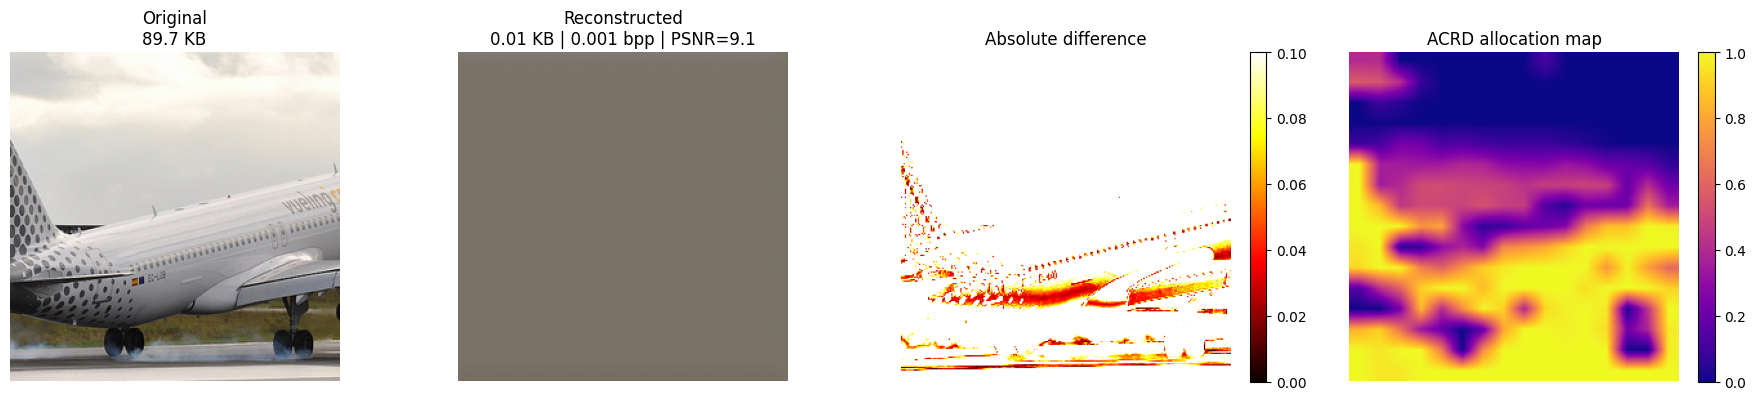

In [22]:
#compressing
import os
import io
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as T
import torch.nn.functional as F


def verify_compression(model, image_source, device=device):
    """
    Full compression verification
    """

    model.eval()

    # support DataParallel
    m = model.module if isinstance(model, nn.DataParallel) else model

    # -----------------------------
    # LOAD IMAGE
    # -----------------------------
    if isinstance(image_source, str):
        pil_img = Image.open(image_source).convert("RGB")
        original_kb = os.path.getsize(image_source) / 1024

        transform = T.Compose([
            T.Resize((256, 256)),
            T.ToTensor()
        ])

        img_tensor = transform(pil_img)
        source_label = os.path.basename(image_source)

    else:
        img_tensor = image_source.clone()

        pil_img = T.ToPILImage()(img_tensor)

        buf = io.BytesIO()
        pil_img.save(buf, format="PNG")

        original_kb = buf.tell() / 1024
        source_label = "input tensor"

    _, H, W = img_tensor.shape
    total_pixels = H * W

    x_in = img_tensor.unsqueezeunsqueeze(0).to(device)

    print("=" * 55)
    print("       COMPRESSION VERIFICATION REPORT")
    print("=" * 55)
    print(f"  Source      : {source_label}")
    print(f"  Resolution  : {W} × {H} pixels")
    print(f"  Total pixels: {total_pixels:,}")
    print(f"  Original size (PNG): {original_kb:.2f} KB")
    print("-" * 55)

  
    with torch.no_grad():
        t0 = time.time()

        logits = m.saliency(x_in)

        y, fb, fe = m.encoder(x_in)

        fh, fw = y.shape[2], y.shape[3]

        W_map, M = m.bit_alloc(logits, fh, fw)

        fe_masked = M[:, m.Cb:] * fe

        encode_time = time.time() - t0

        
        _, _, lls = m.entropy(fb, fe_masked)

        bits_fb = -torch.log2(
            lls["fb"].clamp(1e-9)
        ).sum().item()

        bits_z = -torch.log2(
            lls["z"].clamp(1e-9)
        ).sum().item()

        bits_fe = -torch.log2(
            lls["fe"].clamp(1e-9)
        ).sum().item()

        total_bits = bits_fb + bits_z + bits_fe

        compressed_kb = total_bits / 8 / 1024
        bpp = total_bits / total_pixels

        t1 = time.time()

        out = m(x_in, inference=True)

        if isinstance(out, tuple):
            x_hat = out[0]
        else:
            x_hat = out

        decode_time = time.time() - t1


    orig_np = (
        img_tensor
        .permute(1, 2, 0)
        .numpy()
        .clip(0, 1)
    )

    recon_np = (
        x_hat.squeeze(0)
        .cpu()
        .permute(1, 2, 0)
        .numpy()
        .clip(0, 1)
    )

    mse = np.mean((orig_np - recon_np) ** 2)
    psnr = -10 * np.log10(mse + 1e-8)

    ratio = original_kb / (compressed_kb + 1e-8)

    enh_mask = M[:, m.Cb:].float()
    enh_fraction = enh_mask.mean().item()

    base_bits = bits_fb + bits_z
    enh_bits = bits_fe


    print(f"  Compressed size : {compressed_kb:.2f} KB ({total_bits:,.0f} bits)")
    print(f"  Bits per pixel  : {bpp:.4f} bpp")
    print(f"  Compression ratio: {ratio:.2f}x")
    print(f"  PSNR            : {psnr:.2f} dB")
    print(f"  Encode time     : {encode_time*1000:.1f} ms")
    print(f"  Decode time     : {decode_time*1000:.1f} ms")
    print("-" * 55)
    print(f"  Base bits       : {base_bits:,.0f}")
    print(f"  Enhancement bits: {enh_bits:,.0f}")
    print(f"  Enh used        : {enh_fraction:.1%}")
    print("=" * 55)

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))

    axes[0].imshow(orig_np)
    axes[0].set_title(f"Original\n{original_kb:.1f} KB")

    axes[1].imshow(recon_np)
    axes[1].set_title(
        f"Reconstructed\n"
        f"{compressed_kb:.2f} KB | "
        f"{bpp:.3f} bpp | "
        f"PSNR={psnr:.1f}"
    )

    diff = np.abs(orig_np - recon_np).mean(axis=2)

    im2 = axes[2].imshow(
        diff,
        cmap="hot",
        vmin=0,
        vmax=0.1
    )

    axes[2].set_title("Absolute difference")
    plt.colorbar(im2, ax=axes[2], fraction=0.046)

    w_np = (
        F.interpolate(
            W_map,
            size=(H, W),
            mode="bilinear",
            align_corners=False
        )
        .squeeze()
        .cpu()
        .numpy()
    )

    im3 = axes[3].imshow(
        w_np,
        cmap="plasma",
        vmin=0,
        vmax=1
    )

    axes[3].set_title("ACRD allocation map")
    plt.colorbar(im3, ax=axes[3], fraction=0.046)

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    return {
        "original_kb": original_kb,
        "compressed_kb": compressed_kb,
        "bpp": bpp,
        "ratio": ratio,
        "psnr": psnr
    }



sample_batch = next(iter(val_loader))

sample_img = (
    sample_batch[0][0]
    if isinstance(sample_batch, (list, tuple))
    else sample_batch[0]
)

results = verify_compression(model, sample_img)